In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [6]:
data = pd.read_csv("../../Notes/Cirrhosis.csv")


In [7]:
data_status = data['status'].value_counts(normalize = True)

In [107]:
data.describe()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          312 non-null    int64  
 1   duration       312 non-null    int64  
 2   status         312 non-null    int64  
 3   drug           312 non-null    int64  
 4   age            312 non-null    int64  
 5   sex            312 non-null    int64  
 6   ascites        312 non-null    int64  
 7   hepatomology   312 non-null    int64  
 8   spiders        312 non-null    int64  
 9   edema          312 non-null    float64
 10  bilirubin      312 non-null    float64
 11  cholesterol    284 non-null    float64
 12  albumin        312 non-null    float64
 13  copper         310 non-null    float64
 14  phosphatase    312 non-null    float64
 15  SGOT           312 non-null    float64
 16  triglicerides  282 non-null    float64
 17  platelets      308 non-null    float64
 18  prothrombin    312 no

# Helper Functions

In [9]:
def sigmoid(h):
  return 1/(1+np.exp(-h))

def linear(H):
  return H

def ReLU(H):
  return H*(H>0)

def softmax(H):
  eH = np.exp(H)
  return eH/eH.sum(axis=1 , keepdims=True)

def cross_entropy(y, p_hat):
  return -(1/len(y)) * np.sum(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))

def cat_cross_entropy(Y, P_hat):
  return -(1/len(Y)) * np.sum(np.sum(Y*np.log(P_hat), axis=1), axis=0)

def indices_to_one_hot(data, nb_classes):
  targets = np.array(data).reshape(-1)
  return np.eye(nb_classes)[targets]

def one_hot(y):
  N=len(y)
  K=len(set(y))
  Y= np.zeros((N,K))
  for i in range(N):
    Y[i, y[i]]=1
  return Y

def accuracy(y, y_hat):
  return np.mean(y==y_hat)

def OLS(Y, Y_hat):
  return (1/(2*len(Y)))*np.sum((Y-Y_hat)**2)

def R2(y, y_hat):
  return 1- np.sum((y-y_hat)**2)/np.sum((y-y.mean())**2)

def derivative(Z, a):
  if a == linear:
    return 1

  if a == sigmoid:
    return Z * (1 - Z)

  if a == np.tanh:
    return 1 - Z ** 2

  if a == ReLU:
    return (Z > 0).astype(int)

  else:
    ValueError("Unknown activation function, please add derivative manually")

def k_fold(X, y, K):
    indices = np.random.permutation(len(X))
    folds = np.array_split(indices, K)
    
    fold_accuracy = []

    for i in range(K):
      valid_index = folds[i]
      train_index = np.vstack([folds[j] for j in range(K) if j != i])
    
    return fold_accuracy

# MV LINEAR REGRESSION

In [10]:
class MVLogisticRegression():
  def fit(self, X, y, eta=1e-3, epochs=1e3, show_curve=True):

    epochs = int(epochs)
    N, D = X.shape
    K = len(np.unique(y))
    Y = indices_to_one_hot(y, K).astype(int)

    # Initialize Weights and Biases
    self.W = np.random.randn(D, K)
    self.B = np.random.randn(K)

    # Loss Container
    J = np.zeros(epochs)

    # Gradient Descent
    for epoch in range(epochs):
      P_hat = self.__forward__(X)
      J[epoch] = cat_cross_entropy(Y, P_hat)

      #Weights and Bias Update Rules
      self.W -= eta * (1/N) * X.T @ (P_hat - Y)
      self.B -= eta * (1/N) * np.sum(P_hat - Y, axis=0)

    if show_curve:
      plt.figure()
      plt.plot(J)
      plt.ylabel("$\\mathcal{J}$")
      plt.xlabel("epoch")
      plt.title("Training Curve (MVLR)")

  def __forward__(self, X):
    return softmax(X @ self.W + self.B)

  def predict(self, X):
    return np.argmax(self.__forward__(X), axis=1)

# ANN

In [11]:
class ANN():

  def __init__(self, architecture, activations):
    self.architecture = architecture
    self.activations = activations
    self.L = len(architecture) + 1

  def fit(self, X, y, eta=1e-3, epochs=1e3, show_curve=True):
    epochs = int(epochs)
    ROWS, COLUMNS = X.shape

    # Insert regression code here
    Y = one_hot(y)
    K = Y.shape[1]

    #Initialize Weights and Biases
    self.W = {l: np.random.randn(M[0],M[1]) for
              l, M in enumerate(zip(([COLUMNS]+self.architecture),(self.architecture+[K])),1)}
    self.B = {l: np.random.randn(M) for l, M in enumerate(self.architecture+[K],1)}

    # Activations
    if self.activations is None:
      self.a = {l: ReLU for l in range(1, self.L)}
    else:
      self.a = {l: act for l, act in enumerate(self.activations, 1)}

    self.a[self.L] = softmax

    # Loss Container Array
    J = np.zeros(epochs)

    # Gradient Descent Progression
    for epoch in range(epochs):
      self.__forward__(X)
      J[epoch] = cat_cross_entropy(Y, self.Z[self.L])

      # Back Propagation
      dH = (1/ROWS) * (self.Z[self.L] - Y)
      for l in sorted(self.W.keys(), reverse=True):
        dW = self.Z[l - 1].T@dH
        dB = dH.sum(axis=0)

        self.W[l] -= eta * dW
        self.B[l] -= eta * dB

        if l > 1:
          dZ = dH@self.W[l].T
          dH = dZ * derivative(self.Z[l-1], self.a[l-1])

    if show_curve:
      plt.figure()
      plt.plot(J)
      plt.ylabel("$\\mathcal{J}$")
      plt.xlabel("epoch")
      plt.title("Training Curve (ANN)")

  def __forward__(self, X):
    #Feed Forward
    self.Z = {0: X}
    for l in sorted(self.W.keys()):
      self.Z[l] = self.a[l](self.Z[l-1]@self.W[l] + self.B[l])

  def predict(self, X):
    self.__forward__(X)
    return self.Z[self.L].argmax(axis=1)


In [12]:
mvlr = MVLogisticRegression()

# ANN Implementation

In [ ]:
def main_class_80():
    D = 10
    K = 2
    N = int(K*1e3)

    # Status Implementation
    status_map = {0: 0, 1: 0, 2: 1}
    features = ['age', 'sex', 'ascites', 'hepatomology', 'spiders', 
            'edema', 'bilirubin', 'albumin', 'prothrombin', 'stage']
    
    X0 = data.loc[(data['status'] == 0) | (data['status'] == 1), features].values
    X1 = data.loc[data['status'] == 2, features].values
    X_unscaled = np.vstack((X0, X1))
    X = (X_unscaled - X_unscaled.mean(axis = 0)) / X_unscaled.std(axis = 0)
    y0 = np.zeros(len(X0), dtype = int)
    y1 = np.ones(len(X1), dtype = int)
    y = np.concatenate((y0, y1))
    
    np.random.seed(42)
    shuffle_index = np.random.permutation(len(X))
    split_80 = int(len(X) * 0.8)

    X_TRAIN_80, X_TEST_80 = X[shuffle_index[:split_80]], X[shuffle_index[split_80:]]
    Y_TRAIN_80, Y_TEST_80 = y[shuffle_index[:split_80]], y[shuffle_index[split_80:]]
    
    plt.figure()
    plt.scatter(X_TRAIN_80[:,0],X_TRAIN_80[:,1], c=Y_TRAIN_80, s=6, alpha=0.6)

    my_ann_classifier_80 = ANN(architecture=[22, 11, 2], activations=[np.tanh, np.tanh, sigmoid])
    my_ann_classifier_80.fit(X_TRAIN_80, Y_TRAIN_80, eta=1e-3, epochs=6e4)
    
    y_hat_80 = my_ann_classifier_80.predict(X_TEST_80)
    y_hat_80_train = my_ann_classifier_80.predict(X_TRAIN_80)
   

    mvlr.fit(X_TRAIN_80, Y_TRAIN_80, eta=1e-2, epochs=4000)
    y_hat_80_mvlr = mvlr.predict(X_TEST_80)

    keras_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape = (10,)),
        tf.keras.layers.Dense(22, activation='tanh'),
        tf.keras.layers.Dense(11, activation='tanh'),
        tf.keras.layers.Dense(2, activation='sigmoid')
    ])

    keras_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])
    
    history = keras_model.fit(X_TRAIN_80, Y_TRAIN_80, epochs=35, verbose=0)
    keras_predict = keras_model.predict(X_TEST_80, verbose = 2)
    y_hat_keras = np.argmax(keras_predict, axis=1)
    keras_history = history.history['loss']

    plt.figure()
    plt.plot(keras_history)
    plt.ylabel("J")
    plt.xlabel("Epoch")
    plt.title("Training Curve (Keras ANN)")

   

    

    # print(my_ann_classifier_80.W)
    # print(my_ann_classifier_80.B)
    print(f"Testing Accuracy (ANN): {accuracy(Y_TEST_80,y_hat_80): 0.4f}")
    print(f"Testing Accuracy (MVLR): {accuracy(Y_TEST_80,y_hat_80_mvlr): 0.4f}")
    print(f"Testing Accuracy (Keras ANN): {accuracy(Y_TEST_80, y_hat_keras): 0.4f}")
        
    from matplotlib.colors import ListedColormap
    cmap_bold = ListedColormap(["#FF0000","#0000FF"])
    cmap_light = ListedColormap(["#FFBBBB","#BBBBFF"])

    x1 = np.linspace(X_TRAIN_80[:,0].min() - 1, X_TRAIN_80[:,0].max() + 1, 1000)
    x2 = np.linspace(X_TRAIN_80[:,1].min() - 1, X_TRAIN_80[:,1].max() + 1, 1000)

    xx1, xx2 = np.meshgrid(x1, x2)
    grid_2d = np.c_[xx1.ravel(),xx2.ravel()]
    other_features = np.zeros((len(grid_2d), 8))
    grid_10d = np.hstack((grid_2d, other_features))
    Z = my_ann_classifier_80.predict(grid_10d).reshape(*xx1.shape)

    plt.figure()
    plt.pcolormesh(xx1, xx2, Z, cmap = cmap_light, shading='auto')
    plt.scatter(X_TRAIN_80[:,0], X_TRAIN_80[:,6], c = Y_TRAIN_80, cmap = cmap_bold,alpha=0.2)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    plt.show()

    plt.figure()
    plt.scatter(X_TRAIN_80[:,0],X_TRAIN_80[:,6],c=y_hat_80_train,s=6)

    from sklearn.metrics import confusion_matrix

    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    # Compute matrices
    cm_ann = confusion_matrix(Y_TEST_80, y_hat_80)
    cm_mvlr = confusion_matrix(Y_TEST_80, y_hat_80_mvlr)
    cm_keras = confusion_matrix(Y_TEST_80, y_hat_keras)
    
    sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Stable', 'Deceased'], yticklabels=['Stable', 'Deceased'])
    axes[0].set_title("Custom ANN Confusion Matrix")
    axes[0].set_ylabel("Actual Clinical State")
    axes[0].set_xlabel("Predicted Label")
    
    sns.heatmap(cm_mvlr, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
    xticklabels=['Stable', 'Deceased'], yticklabels=['Stable', 'Deceased'])
    axes[1].set_title("MVLR Confusion Matrix")
    axes[1].set_xlabel("Predicted Label")

    
    sns.heatmap(cm_keras, annot=True, fmt='d', cmap='Greens', ax=axes[2],
    xticklabels=['Stable', 'Deceased'], yticklabels=['Stable', 'Deceased'])
    axes[2].set_title("Keras ANN Confusion Matrix")
    axes[2].set_xlabel("Predicted Label")
    axes[2].set_ylabel("Actual Clinical State")

    features_corr = ['age', 'sex', 'ascites', 'hepatomology', 'spiders', 
            'edema', 'bilirubin', 'albumin', 'prothrombin', 'stage', 'status']
    plt.figure(figsize=(12, 8))
    correlation = data[features_corr]
    sns.heatmap(correlation.corr(numeric_only=True), annot=True, cmap = 'coolwarm')
    plt.show()

2/2 - 0s - 34ms/step
Testing Accuracy (ANN):  0.7937
Testing Accuracy (MVLR):  0.8571
Testing Accuracy (Keras ANN):  0.8095


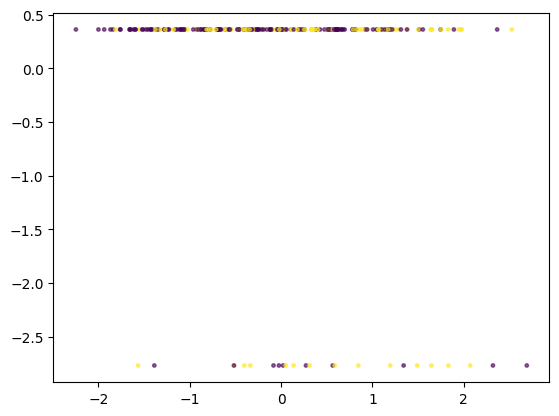

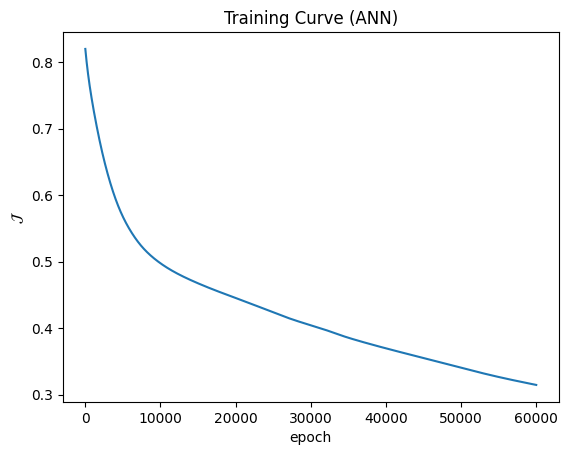

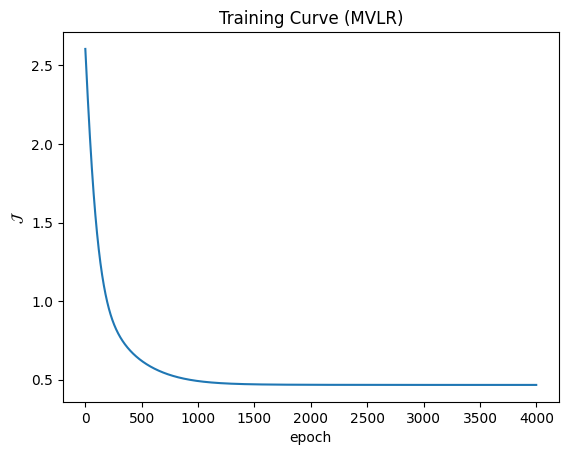

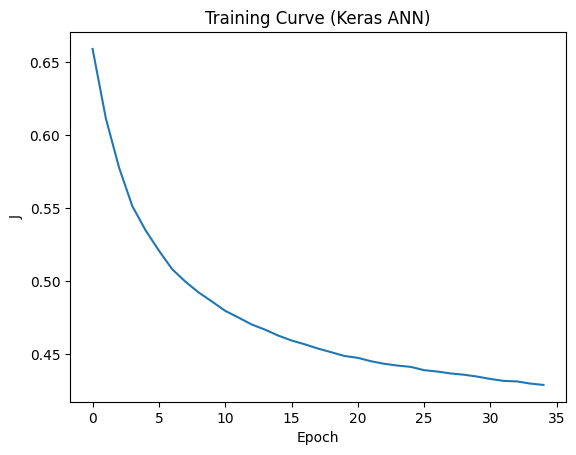

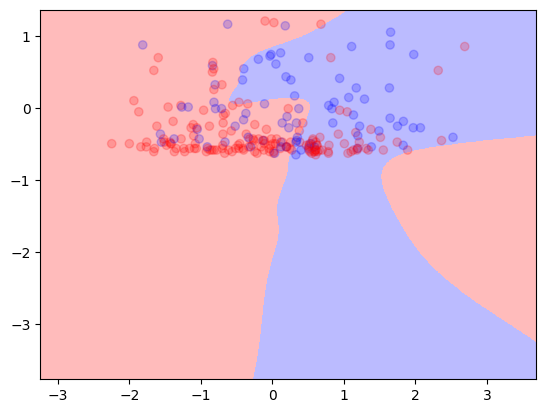

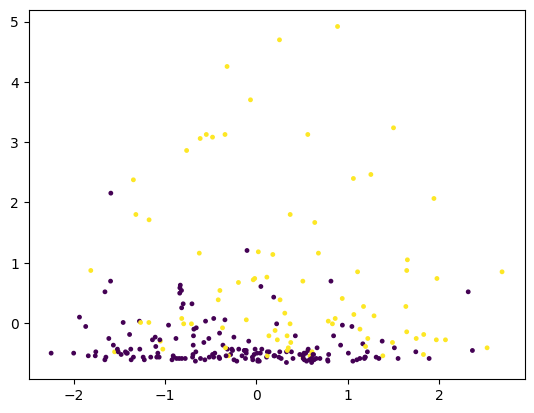

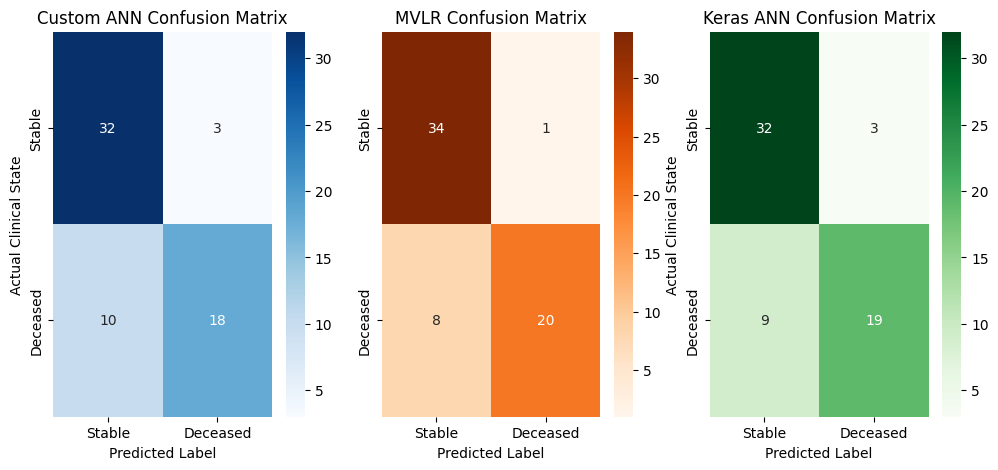

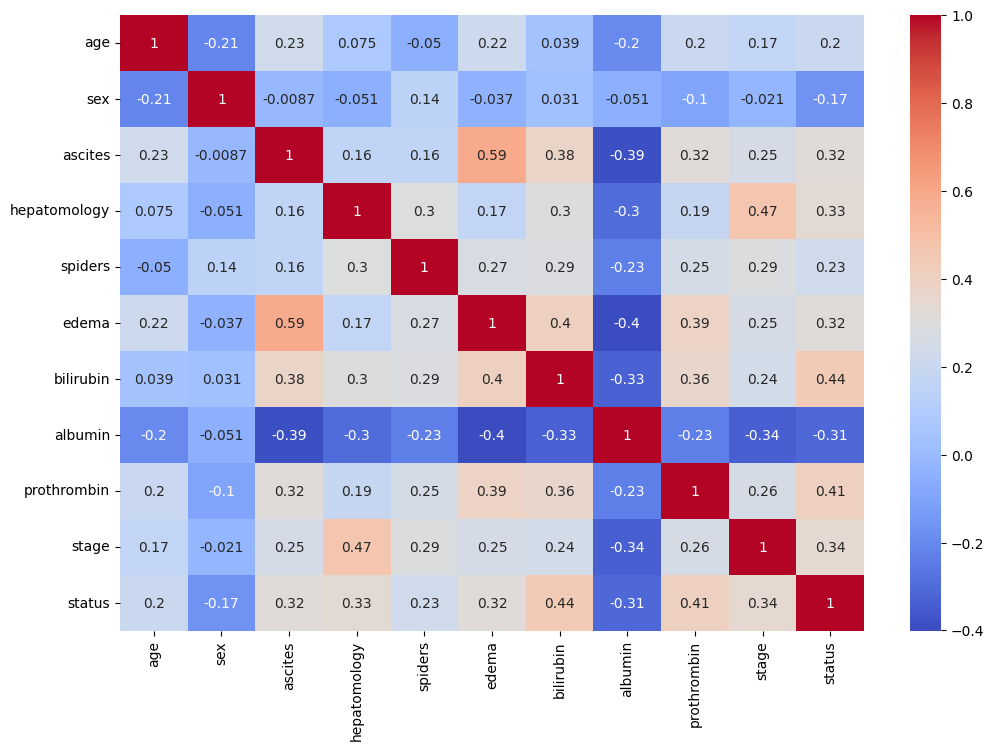

In [106]:
if __name__ == "__main__":
  main_class_80()

# Training Curve